In [ ]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
from jax import tree_util as jtu
jax.config.update('jax_enable_x64', True)

# Others
from matplotlib import pyplot as plt

# This
from numerics import *
from seismic import *
from HazCalculator import *

In [66]:
# Simple site
x_site, y_site = 0., 0.
vs30 = 760
z1p0, z2p5 = 1.3, 0.
site = Site(x_site, y_site, vs30, z1p0, z2p5, 0.)

# Fault 1 is large, faraway earthquakes; fault 2 is small, close
x_fault1, y_fault1 = 50., 49.
theta1, width1 = 225, 1.5
mfd1, M_marg1 = MFD(2.5, 1.25), jnp.array([7., 8.5])
x_fault2, y_fault2 = -20., 15.
theta2, width2 = 30, 2.7
mfd2, M_marg2 = MFD(4.1, 1.8), jnp.array([5., 6.])
# Shared fault params
z_hyp = 1.5
z_tor = 1.
dip = 45
rake = 0.
# Fault 1
fault1 = Fault(x_fault1, x_fault2, z_hyp, z_tor, theta1, dip, rake, width1, 0., mfd1)
fault2 = Fault(x_fault2, y_fault2, z_hyp, z_tor, theta2, dip, rake, width2, 0., mfd2)
faults = [fault1, fault2]
# Scenario magnitude tree
M_scn_tree = jnp.stack([M_marg1, M_marg2])

# GMMs
gmms = [gmm_ASK14, gmm_BSSA14, gmm_CB14, gmm_CY14, gmm_Idriss14]
#c_AAY14 = 1.674
#gmms = gmms + [gmm_epi_AAY14(gmm, c_AAY14) for gmm in gmms] + [gmm_epi_AAY14(gmm, -c_AAY14) for gmm in gmms]
# GMM weights
w_gmms = jnp.ones(len(gmms)) / len(gmms)
gmmlt = GMMLT(gmms, w_gmms)

# Intensity measures + period
n_ims = 10
ims = jnp.logspace(-3, -1, n_ims, base = 10)
im0 = (ims[-1] + ims[0])/2
T = 0.1

PCE 6, Taylor 5 done
PCE 6, Taylor 7 done
PCE 6, Taylor 9 done
PCE 6, Taylor 12 done
PCE 7, Taylor 5 done
PCE 7, Taylor 7 done
PCE 7, Taylor 9 done
PCE 7, Taylor 12 done
PCE 8, Taylor 5 done
PCE 8, Taylor 7 done
PCE 8, Taylor 9 done
PCE 8, Taylor 12 done


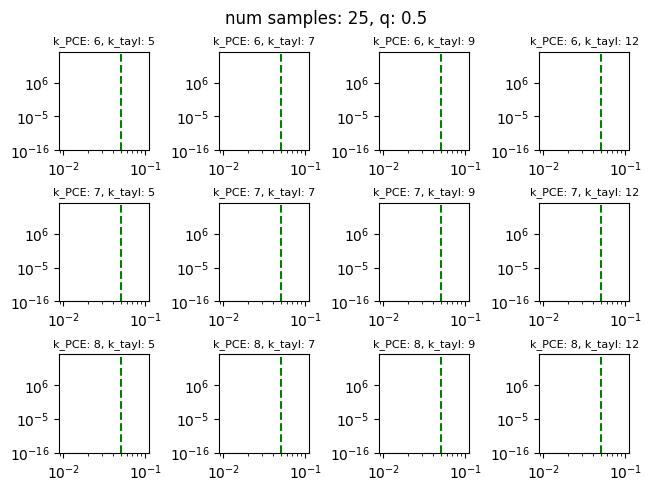

PCE 6, Taylor 5 done
PCE 6, Taylor 7 done
PCE 6, Taylor 9 done
PCE 6, Taylor 12 done


KeyboardInterrupt: 

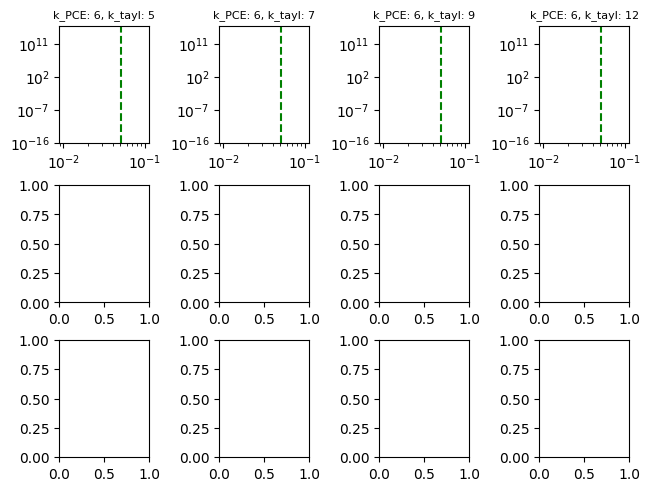

In [68]:
haz_calc = HazCalculator(gmmlt)
haz_mu = haz_calc.calc_haz(ims, T, site, faults)
haz_std = haz_calc.calc_epi_haz(ims, T, site, faults)
marg_haz_mu = haz_calc.calc_haz(ims, T, site, faults, jnp.stack([M_marg1, M_marg2]))
marg_haz_std = haz_calc.calc_epi_haz(ims, T, site, faults, jnp.stack([M_marg1, M_marg2]))

# TEST
scn_fault1_vec = Scenario(0., T, site, fault1).tree_tovec()
scn_fault2_vec = Scenario(0., T, site, fault2).tree_tovec()
params_idcs = jnp.array([0, 8])
params_a = jnp.array([4., 0.5])
params_b = jnp.array([0.1, 6.])
n_sample = 25
k_KL = 5
m_os_KL = 1.5
k_cheb_KL = 4
k_phs_KL = 3
k_poly_KL = 3

k_PCE = 8
k_taylor = 7
q = 0.8

n_eval = 250
X_eval = jrnd.normal(jrnd.key(18), (n_eval, k_KL))

params_transforms = [lambda x: x, jnp.exp]

for m_sample in [25, 50, 75, 100]:
    for q in [0.5, 0.625, 0.75, 0.85]:
        fig,ax = plt.subplots(3, 4, layout = 'constrained')
        for i,k_PCE in enumerate([6, 7, 8]):
            for j,k_taylor in enumerate([5, 7, 9, 12]):
                haz_est = haz_calc.KLtPCE(scn_fault2_vec, 
                                        params_idcs, params_transforms, 
                                        params_a, params_b, 
                                        n_sample, C_Lacour, 
                                        k_KL, m_os_KL, k_cheb_KL, k_phs_KL, k_poly_KL)(T, site, faults, im0, k_taylor, m_sample, k_PCE, q = q)
                out = jax.vmap(haz_est, in_axes = (0, None))(ims, X_eval)

                mu, std = jnp.exp(jnp.log(out).mean(axis = -1)), jnp.exp(jnp.log(out).std(axis = -1))
                err_mu = (jnp.exp(jnp.log(mu / haz_mu)) ** 2) ** (1 / 2)
                err_std = (jnp.exp(jnp.log(std / haz_std)) ** 2) ** (1 / 2)

                ax[i,j].plot(ims, err_mu, c = 'k')
                ax[i,j].plot(ims, err_std, c = 'k', ls = '--')
                ax[i,j].set_xscale('log')
                ax[i,j].set_yscale('log')
                ax[i,j].set_ylim(1e-16, 1e16)
                ax[i,j].set_title('k_PCE: %s, k_tayl: %s'%(k_PCE, k_taylor), fontsize = 8)
                ax[i,j].axvline(im0, ls = '--', c = 'g')
                print('PCE %s, Taylor %s done'%(k_PCE, k_taylor))
        plt.suptitle('num samples: %s, q: %s'%(m_sample, q))
        plt.show()